In [11]:
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

device = 'cuda' if torch.cuda.is_available() else 'cpu'
project_dir = os.path.dirname(os.getcwd())
sys.path.append(project_dir)

from utils.plots import plot_training_metrics
from utils.train import evaluate_model
from utils.summary import get_model_stats
from utils.losses import Accuracy, MIoU, MulticlassF1Score, PrecisionRecallF1

# Helper Funcs

In [22]:
def get_predictions(model, dataloader, device='cpu'):
    model.to(device)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for images, lbls in dataloader:
            images = images.to(device)  # ✅ Assign back to variable
            lbls = lbls.to(device)      # ✅ Assign back to variable
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            labels.extend(lbls.cpu().numpy())
    return np.array(preds), np.array(labels)


# MNIST

In [ ]:
from data.mnist import get_mnist_pipeline
import models.baseline as mlp


_, _, test_loader = get_mnist_pipeline(batch_size=128, val_split=0)
sample_x, sample_y = next(iter(test_loader))

# can plot some images
def show_images():
    pass

In [ ]:
teacher = mlp.mnist1200().to(device)
smaller = mlp.mnist800().to(device)
student = mlp.mnist800().to(device)
trnsfr1 = mlp.mnist800().to(device)
trnsfr2 = mlp.mnist800().to(device)

sample = sample_x.to(device)
with torch.no_grad():
    print("MNIST1200 stats:")
    for name, param in get_model_stats(teacher, sample.shape).items():
        print(f"{name}: {param}")
    print("MNIST800 stats:")
    for name, param in get_model_stats(student, sample.shape).items():
        print(f"{name}: {param}")

teacher_path = '../models/final_weights/mnist_teacher.pth'
smaller_path = '../models/final_weights/mnist_smaller.pth'
student_path = '../models/final_weights/mnist_student_t5.pth'
trnsfr1_path = '../models/final_weights/mnist_transfer_t3_a70_0.pth'
trnsfr2_path = '../models/final_weights/mnist_reference.pth'

teacher_state = torch.load(teacher_path, map_location=device)
smaller_state = torch.load(smaller_path, map_location=device)
student_state = torch.load(student_path, map_location=device)
trnsfr1_state = torch.load(trnsfr1_path, map_location=device)
trnsfr2_state = torch.load(trnsfr2_path, map_location=device)

teacher.load_state_dict(teacher_state['state_dict'])
smaller.load_state_dict(smaller_state['state_dict'])
student.load_state_dict(student_state['state_dict'])
trnsfr1.load_state_dict(trnsfr1_state['state_dict'])
trnsfr2.load_state_dict(trnsfr2_state['state_dict'])

teacher_test_acc = evaluate_model(test_loader, teacher, Accuracy(), device)
smaller_test_acc = evaluate_model(test_loader, smaller, Accuracy(), device)
student_test_acc = evaluate_model(test_loader, student, Accuracy(), device)
trnsfr1_test_acc = evaluate_model(test_loader, trnsfr1, Accuracy(), device)
trnsfr2_test_acc = evaluate_model(test_loader, trnsfr2, Accuracy(), device)

print(f"Teacher: Val Accuracy: {teacher_state['accuracy']:.4f}")
print(f"Smaller: Val Accuracy: {smaller_state['accuracy']:.4f}")
print(f"Student: Val Accuracy: {student_state['accuracy']:.4f}")
print(f"trnsfr1: Val Accuracy: {trnsfr1_state['accuracy']:.4f}")
print(f"trnsfr2: Val Accuracy: {trnsfr2_state['accuracy']:.4f}")

print(f"Teacher: Test Accuracy: {teacher_test_acc:.4f}")
print(f"Smaller: Test Accuracy: {smaller_test_acc:.4f}")
print(f"Student: Test Accuracy: {student_test_acc:.4f}")
print(f"trnsfr1: Test Accuracy: {trnsfr1_test_acc:.4f}")
print(f"trnsfr2: Test Accuracy: {trnsfr2_test_acc:.4f}")

MNIST1200 stats:
flops: 490598400
params: 3836410
MNIST800 stats:
flops: 245145600
params: 1917610
evaluating...: 100%|██████████| 79/79 [00:02<00:00, 32.43it/s]
Teacher: Val Accuracy: 0.9908
Smaller: Val Accuracy: 0.9873
Student: Val Accuracy: 0.9886
trnsfr1: Val Accuracy: 0.9906
trnsfr2: Val Accuracy: 0.9911
Teacher: Test Accuracy: 0.9908
Smaller: Test Accuracy: 0.9873
Student: Test Accuracy: 0.9886
trnsfr1: Test Accuracy: 0.9725
trnsfr2: Test Accuracy: 0.8935


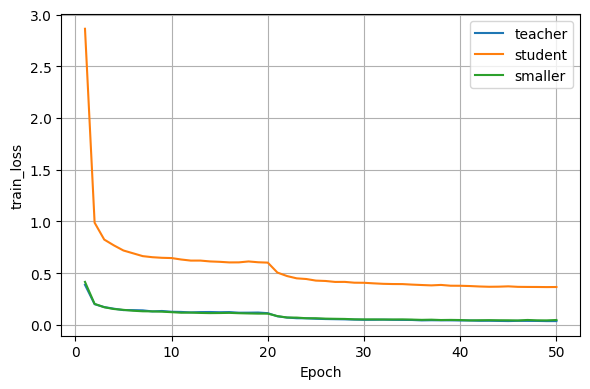

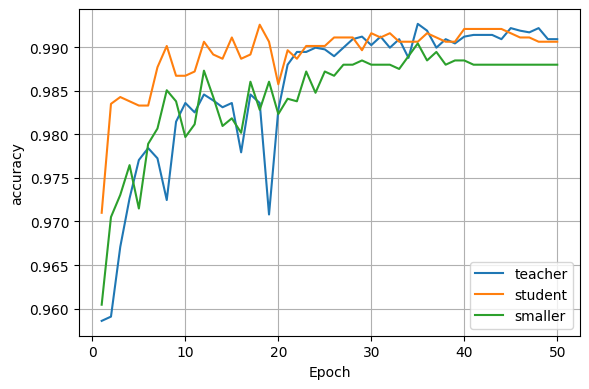

In [9]:
import os
import json
import matplotlib.pyplot as plt

project_dir = '..'  # Replace with your actual project directory

models = ['teacher', 'student', 'smaller']
collection = []
with open(os.path.join(project_dir, 'data/states/mnist_teacher.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/mnist_student_t5.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/mnist_smaller.json'), 'r') as f:
    collection.append(json.load(f))

num_metrics = len(collection[0])
epochs = range(1, len(next(iter(collection[0].values()))) + 1)

for i, k in enumerate(collection[0].keys()):
    plt.figure(figsize=(6, 4))
    for j in range(len(collection)):
        plt.plot(epochs, collection[j][k], label=f"{models[j]}")
    plt.xlabel("Epoch")
    plt.ylabel(k)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

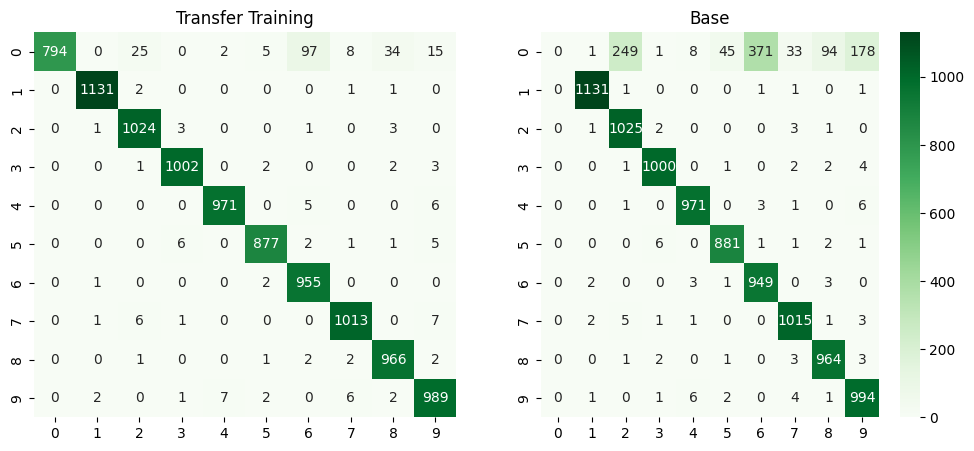

In [34]:
# Get predictions for both models
preds_transfer, labels = get_predictions(trnsfr1, test_loader, device)
preds_original, _ = get_predictions(trnsfr2, test_loader, device)

# Compute confusion matrices
cm_transfer = confusion_matrix(labels, preds_transfer)
cm_original = confusion_matrix(labels, preds_original)

# Compute min/max values for consistent color scaling
vmin = min(cm_transfer.min(), cm_original.min())
vmax = max(cm_transfer.max(), cm_original.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1]})  # Same width ratio

# Left heatmap (No color bar)
sns.heatmap(cm_transfer, annot=True, fmt="d", cmap="Greens", ax=axes[0], vmin=vmin, vmax=vmax, cbar=False)
axes[0].set_title("Transfer Training")

# Right heatmap (With color bar)
sns.heatmap(cm_original, annot=True, fmt="d", cmap="Greens", ax=axes[1], vmin=vmin, vmax=vmax, cbar=True)
axes[1].set_title("Base")

plt.show()

In [35]:
del teacher
del smaller
del student
del trnsfr1
del trnsfr2

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

CUDA cache emptied.


# CIFAR

In [38]:
from data.cifar10 import get_cifar10_pipeline
from models.resnet import resnet34, resnet50


_, _, test_loader = get_cifar10_pipeline(batch_size=128, val_split=0)
sample_x, sample_y = next(iter(test_loader))
print(sample_x.shape)
print(sample_y.shape)

# can plot some images
def show_images():
    pass

Files already downloaded and verified
Files already downloaded and verified
torch.Size([128, 3, 32, 32])
torch.Size([128])


In [ ]:
teacher = resnet34().to(device)
larger = resnet50().to(device)
student = resnet50().to(device)
distill = resnet50().to(device)

sample = sample_x.to(device)
with torch.no_grad():
    print("ResNet34 stats:")
    for name, param in get_model_stats(teacher, sample.shape).items():
        print(f"{name}: {param}")
    print("ResNet50 stats:")
    for name, param in get_model_stats(student, sample.shape).items():
        print(f"{name}: {param}")

teacher_path = '../models/final_weights/cifar10_resnet34_teacher.pth'
larger_path = '../models/final_weights/cifar10_resnet50_larger.pth'
student_path = '../models/final_weights/cifar10_resnet50_student.pth'
distill_path = '../models/final_weights/cifar10_resnet50_a20.pth'

teacher_state = torch.load(teacher_path, map_location=device)
larger_state = torch.load(larger_path, map_location=device)
student_state = torch.load(student_path, map_location=device)
distill_state = torch.load(distill_path, map_location=device)

teacher.load_state_dict(teacher_state['state_dict'])
larger.load_state_dict(larger_state['state_dict'])
student.load_state_dict(student_state['state_dict'])
distill.load_state_dict(distill_state['state_dict'])

teacher_test_acc = evaluate_model(test_loader, teacher, Accuracy(), device)
larger_test_acc = evaluate_model(test_loader, larger, Accuracy(), device)
student_test_acc = evaluate_model(test_loader, student, Accuracy(), device)
distill_test_acc = evaluate_model(test_loader, distill, Accuracy(), device)

print(f"Teacher: Val Accuracy: {teacher_state['accuracy']:.4f}")
print(f"Larger: Val Accuracy: {larger_state['accuracy']:.4f}")
print(f"Student: Val Accuracy: {student_state['accuracy']:.4f}")
print(f"Distill: Val Accuracy: {distill_state['accuracy']:.4f}")

print(f"Teacher: Test Accuracy: {teacher_test_acc:.4f}")
print(f"Larger: Test Accuracy: {larger_test_acc:.4f}")
print(f"Student: Test Accuracy: {student_test_acc:.4f}")
print(f"Distill: Test Accuracy: {distill_test_acc:.4f}")

Unsupported operator aten::add_ encountered 16 time(s)
Unsupported operator aten::log_softmax encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
layer1.0.shortcut, layer1.1.shortcut, layer1.2.shortcut, layer2.1.shortcut, layer2.2.shortcut, layer2.3.shortcut, layer3.1.shortcut, layer3.2.shortcut, layer3.3.shortcut, layer3.4.shortcut, layer3.5.shortcut, layer4.1.shortcut, layer4.2.shortcut


ResNet34 stats:
flops: 148666712064
params: 21282122
ResNet50 stats:


Unsupported operator aten::add_ encountered 16 time(s)
Unsupported operator aten::log_softmax encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
layer1.1.shortcut, layer1.2.shortcut, layer2.1.shortcut, layer2.2.shortcut, layer2.3.shortcut, layer3.1.shortcut, layer3.2.shortcut, layer3.3.shortcut, layer3.4.shortcut, layer3.5.shortcut, layer4.1.shortcut, layer4.2.shortcut


flops: 167005126656
params: 23520842
evaluating...: 100%|██████████| 79/79 [00:05<00:00, 14.08it/s]
Teacher: Val Accuracy: 0.9216
Larger: Val Accuracy: 0.9119
Student: Val Accuracy: 0.9147
Teacher: Test Accuracy: 0.9166
Larger: Test Accuracy: 0.9057
Student: Test Accuracy: 0.9200


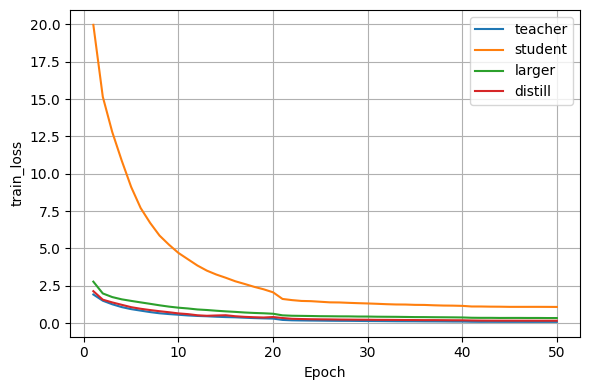

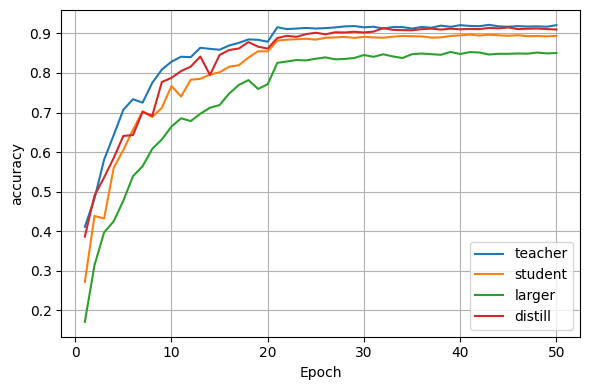

In [45]:
import os
import json
import matplotlib.pyplot as plt

project_dir = '..'  # Replace with your actual project directory

models = ['teacher', 'student', 'larger', 'distill']
collection = []
with open(os.path.join(project_dir, 'data/states/cifar10_resnet34_teacher.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/cifar10_resnet50_student.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/cifar10_resnet50_larger.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/cifar10_resnet50_a20.json'), 'r') as f:
    collection.append(json.load(f))

num_metrics = len(collection[0])
epochs = range(1, len(next(iter(collection[0].values()))) + 1)

for i, k in enumerate(collection[0].keys()):
    plt.figure(figsize=(6, 4))
    for j in range(len(collection)):
        plt.plot(epochs, collection[j][k], label=f"{models[j]}")
    plt.xlabel("Epoch")
    plt.ylabel(k)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
del teacher
del larger
del student
del distill

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

CUDA cache emptied.


# VOC

In [ ]:
from data.voc import get_voc_pipeline_test
from models.unet import UNet18, UNet34
from utils.losses import MIoU
from utils.train import evaluate_miou

_, _, test_loader = get_voc_pipeline_test(batch_size=128, val_split=0)
sample_x, sample_y = next(iter(test_loader))

# can plot some images
def show_images():
    pass

In [ ]:
teacher = UNet34(num_classes=21, pretrained=True).to(device)
smaller = UNet18(num_classes=21, pretrained=True).to(device)
student = UNet18(num_classes=21, pretrained=True).to(device)

sample = sample_x.to(device)
with torch.no_grad():
    print("UNet34 stats:")
    for name, param in get_model_stats(teacher, sample.shape).items():
        print(f"{name}: {param}")
    print("UNet18 stats:")
    for name, param in get_model_stats(student, sample.shape).items():
        print(f"{name}: {param}")

teacher_path = '../models/final_weights/voc_unet34_teacher.pth'
smaller_path = '../models/final_weights/voc_unet18_smaller.pth'
student_path = '../models/final_weights/voc_unet18_student.pth'

teacher_state = torch.load(teacher_path, map_location=device)
smaller_state = torch.load(smaller_path, map_location=device)
student_state = torch.load(student_path, map_location=device)

teacher.load_state_dict(teacher_state['state_dict'])
smaller.load_state_dict(smaller_state['state_dict'])
student.load_state_dict(student_state['state_dict'])

teacher_test = evaluate_miou(test_loader, teacher, MIoU(), device)
smaller_test = evaluate_miou(test_loader, smaller, MIoU(), device)
student_test = evaluate_miou(test_loader, student, MIoU(), device)

print(f"Teacher: Val MIoU: {teacher_state['miou']:.4f}")
print(f"Smaller: Val MIoU: {smaller_state['miou']:.4f}")
print(f"Student: Val MIoU: {student_state['miou']:.4f}")

print(f"Teacher: Test MIoU: {teacher_test:.4f}")
print(f"Smaller: Test MIoU: {smaller_test:.4f}")
print(f"Student: Test MIoU: {student_test:.4f}")

In [ ]:
import os
import json
import matplotlib.pyplot as plt

project_dir = '..'  # Replace with your actual project directory

models = ['teacher', 'student', 'smaller']
collection = []
with open(os.path.join(project_dir, 'data/states/mnist_teacher.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/mnist_student_t5.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/mnist_smaller.json'), 'r') as f:
    collection.append(json.load(f))

num_metrics = len(collection[0])
epochs = range(1, len(next(iter(collection[0].values()))) + 1)

for i, k in enumerate(collection[0].keys()):
    plt.figure(figsize=(6, 4))
    for j in range(len(collection)):
        plt.plot(epochs, collection[j][k], label=f"{models[j]}")
    plt.xlabel("Epoch")
    plt.ylabel(k)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt

# Pascal VOC has 21 classes (including background)
VOC_CLASS_COLORS = {
    0: (0, 0, 0),       # Background (black)
    1: (128, 0, 0),     # Aeroplane
    2: (0, 128, 0),     # Bicycle
    3: (128, 128, 0),   # Bird
    4: (0, 0, 128),     # Boat
    5: (128, 0, 128),   # Bottle
    6: (0, 128, 128),   # Bus
    7: (128, 128, 128), # Car
    8: (64, 0, 0),      # Cat
    9: (192, 0, 0),     # Chair
    10: (64, 128, 0),   # Cow
    11: (192, 128, 0),  # Dining Table
    12: (64, 0, 128),   # Dog
    13: (192, 0, 128),  # Horse
    14: (64, 128, 128), # Motorbike
    15: (192, 128, 128),# Person
    16: (0, 64, 0),     # Potted Plant
    17: (128, 64, 0),   # Sheep
    18: (0, 192, 0),    # Sofa
    19: (128, 192, 0),  # Train
    20: (0, 64, 128)    # TV/Monitor
}

def decode_segmentation(mask):
    """Convert Pascal VOC segmentation mask to RGB image."""
    h, w = mask.shape
    rgb_image = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in VOC_CLASS_COLORS.items():
        rgb_image[mask == class_id] = color  # Assign color to matching class pixels

    return rgb_image

def get_segmentation_mask(model, image, device='cuda'):
    model.to(device)
    model.eval()
    with torch.no_grad():
        image = image.to(device)
        output = model(image.unsqueeze(0))  # Add batch dimension
        mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()
    return mask

# Get segmentation masks
mask_A = get_segmentation_mask(teacher, sample_x)
mask_B = get_segmentation_mask(student, sample_x)

# Convert masks to RGB for better visualization (assuming you have `decode_segmentation()`)
mask_A_rgb = decode_segmentation(mask_A)
mask_B_rgb = decode_segmentation(mask_B)

# Plot original image + both segmentation masks
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(image.permute(1, 2, 0).cpu().numpy())  # Convert tensor to image format
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask_A_rgb)
axes[1].set_title("Model A Segmentation")
axes[1].axis("off")

axes[2].imshow(mask_B_rgb)
axes[2].set_title("Model B Segmentation")
axes[2].axis("off")

plt.show()


In [ ]:
del teacher
del smaller
del student
del trnsfr1
del trnsfr2

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")